# Probe Results Viewer

Auto-discovers all models and features in a results directory.
Handles both result formats (with/without probe-mode wrapper) and all result types:
- **Standard probes** (`*.json`): score per layer
- **Per-patch probes** (`*_per_patch.json`): score per layer × patch position
- **Compositional probes** (`*_compositional.json`): atomic/pair/delta scores per layer

In [6]:
# ── Configuration ────────────────────────────────────────────────────────────
import os

RESULTS_ROOT = os.path.join("..", "results")

# Which experiment subdirectory to load.  Set to None to list available ones.
EXPERIMENT = "patch_features_real"   # e.g. "real", "synthetic", "synth", "corruption-synth", "corruption-real"

# Which probe mode to use from files that carry a mode wrapper (e.g. mean_ctx / last_ctx).
# Set to None to use the first available mode.
PROBE_MODE = "mean_ctx"

# Override model display names (optional).  Keys are file stems, values are labels.
MODEL_LABELS: dict[str, str] = {
    # "moiraie": "MoiraiE",
    # "moiraic": "MoiraiC",
}

# Optional: restrict which features to show (None → show all)
FEATURES_FILTER: list[str] | None = None

# Figures per row in the overview grid
GRID_COLS = 4

# Figure output directory (None → don't save)
SAVE_DIR: str | None = "/srv/disk00/ctadler/tsfm-mi-experiments/linear_probing/exp-001-per-patch-local/figures"  # e.g. "../figures"
# ─────────────────────────────────────────────────────────────────────────────

In [7]:
import glob
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})


# ── Helpers ───────────────────────────────────────────────────────────────────

def list_experiments(root: str) -> list[str]:
    return sorted(p.name for p in Path(root).iterdir() if p.is_dir())


def _is_mode_wrapped(raw: dict) -> bool:
    """Return True if the JSON has a probe-mode wrapper (e.g. mean_ctx → {...})."""
    first_val = next(iter(raw.values()))
    if not isinstance(first_val, dict):
        return False
    # If first value's values are dicts of floats/NaN → wrapped
    inner_val = next(iter(first_val.values()))
    return isinstance(inner_val, dict)


def load_standard(path: str, mode: str | None) -> dict[str, dict[str, dict[int, float]]]:
    """Load a standard probe JSON.
    
    Returns: {probe_mode: {feature: {layer: score}}}
    For flat files (no mode wrapper) the mode key is 'default'.
    """
    with open(path) as f:
        raw = json.load(f)

    if _is_mode_wrapped(raw):
        # Pick requested mode, or first available
        available = list(raw.keys())
        chosen = mode if (mode and mode in raw) else available[0]
        data = raw[chosen]
        return {
            chosen: {
                feat: {int(k): v for k, v in layers.items()}
                for feat, layers in data.items()
            }
        }
    else:
        return {
        "default": {
                feat: {int(k): v for k, v in layers.items()}
                for feat, layers in raw.items()
            }
        }


def load_per_patch(path: str) -> dict[str, dict[int, dict[int, float]]]:
    """Load a *_per_patch.json or *_patch_features.json.

    Both share the shape {feature: {layer: {patch: score}}}.
    Returns {feature: {layer: {patch: score}}}.
    """
    with open(path) as f:
        raw = json.load(f)
    return {
        feat: {int(l): {int(p): v for p, v in pd.items()} for l, pd in ld.items()}
        for feat, ld in raw.items()
    }


def load_compositional(path: str, mode: str | None) -> dict[str, dict[str, dict[int, dict[str, float]]]]:
    """Load a *_compositional.json.
    
    Returns: {probe_mode: {pair: {layer: {atomic/pair/delta: score}}}}
    """
    with open(path) as f:
        raw = json.load(f)

    if _is_mode_wrapped(raw):
        available = list(raw.keys())
        chosen = mode if (mode and mode in raw) else available[0]
        data = raw[chosen]
    else:
        chosen = "default"
        data = raw

    return {
        chosen: {
            pair: {int(layer): scores for layer, scores in layer_dict.items()}
            for pair, layer_dict in data.items()
        }
    }


def load_metadata(results_dir: str) -> dict[str, dict]:
    meta_path = os.path.join(results_dir, "metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            return json.load(f)["features"]
    return {}


def _scores_to_grid(layer_patch: dict[int, dict[int, float]]) -> np.ndarray:
    layers = sorted(layer_patch)
    patches = sorted(layer_patch[layers[0]])
    return np.array([[layer_patch[l].get(p, float("nan")) for p in patches] for l in layers])


def _model_label(stem: str) -> str:
    return MODEL_LABELS.get(stem, stem)


def _save(fig, name: str) -> None:
    if SAVE_DIR:
        os.makedirs(SAVE_DIR, exist_ok=True)
        fig.savefig(os.path.join(SAVE_DIR, f"{name}.pdf"), bbox_inches="tight")


# ── Auto-discover ─────────────────────────────────────────────────────────────

experiments = list_experiments(RESULTS_ROOT)
print("Available experiments:", experiments)

if EXPERIMENT is None:
    raise ValueError("Set EXPERIMENT to one of the experiments listed above.")

results_dir = os.path.join(RESULTS_ROOT, EXPERIMENT)
feature_meta = load_metadata(results_dir)

# Standard probe files
standard_paths = {
    Path(p).stem: p
    for p in sorted(glob.glob(os.path.join(results_dir, "*.json")))
    if Path(p).stem not in ("metadata",)
    and not Path(p).stem.endswith("_per_patch")
    and not Path(p).stem.endswith("_patch_features")
    and not Path(p).stem.endswith("_compositional")
}

# Per-patch files (broadcast-label per-patch, EXP-000 style)
per_patch_paths = {
    Path(p).stem.replace("_per_patch", ""): p
    for p in sorted(glob.glob(os.path.join(results_dir, "*_per_patch.json")))
}

# Per-patch *local* feature files (EXP-001 style: labels computed per patch)
patch_feature_paths = {
    Path(p).stem.replace("_patch_features", ""): p
    for p in sorted(glob.glob(os.path.join(results_dir, "*_patch_features.json")))
}

# Compositional files
compositional_paths = {
    Path(p).stem.replace("_compositional", ""): p
    for p in sorted(glob.glob(os.path.join(results_dir, "*_compositional.json")))
}

print(f"\nExperiment    : {EXPERIMENT}")
print(f"Standard      : {list(standard_paths)}")
print(f"Per-patch     : {list(per_patch_paths)}")
print(f"Patch-features: {list(patch_feature_paths)}")
print(f"Compositional : {list(compositional_paths)}")

Available experiments: ['corruption-real', 'corruption-synth', 'patch_features', 'patch_features_real', 'real', 'synth', 'synthetic']

Experiment    : patch_features_real
Standard      : ['moiraic', 'moiraie']
Per-patch     : ['moiraic', 'moiraie']
Patch-features: ['moiraic', 'moiraie']
Compositional : []


In [8]:
# ── Load standard probe results ───────────────────────────────────────────────
# standard_results[model_stem][probe_mode][feature][layer] = score

standard_results: dict[str, dict[str, dict[str, dict[int, float]]]] = {}
for stem, path in standard_paths.items():
    standard_results[stem] = load_standard(path, PROBE_MODE)

# Gather all (model, mode) pairs and all features
all_model_modes: list[tuple[str, str]] = [
    (model, mode)
    for model, modes in standard_results.items()
    for mode in modes
]
all_features_standard: list[str] = list(dict.fromkeys(
    feat
    for model, modes in standard_results.items()
    for mode_data in modes.values()
    for feat in mode_data
))

if FEATURES_FILTER:
    all_features_standard = [f for f in all_features_standard if f in FEATURES_FILTER]

# Layer range
all_layers = sorted({
    layer
    for model, modes in standard_results.items()
    for mode_data in modes.values()
    for feat_data in mode_data.values()
    for layer in feat_data
})

# Color palette — one color per (model, mode) series
prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
series_colors = {
    (model, mode): prop_cycle[i % len(prop_cycle)]
    for i, (model, mode) in enumerate(all_model_modes)
}

def series_label(model: str, mode: str) -> str:
    label = _model_label(model)
    if mode not in ("default", PROBE_MODE or "default"):
        label += f" ({mode})"
    return label

print(f"Series  : {all_model_modes}")
print(f"Features: {all_features_standard}")
print(f"Layers  : {all_layers}")

Series  : [('moiraic', 'mean_ctx'), ('moiraie', 'mean_ctx')]
Features: ['stl_trend_strength', 'stl_seasonal_strength', 'fft_dominant_period', 'fft_top1_power_frac', 'spectral_flatness', 'adf_pvalue', 'hurst_exponent', 'sample_entropy', 'n_changepoints', 'context_std', 'context_acf_lag1', 'dataset_id']
Layers  : [-1, 0, 1, 2, 3, 4, 5, 6, 7]


## Standard probe scores by layer

Each subplot shows probe accuracy / R² across transformer layers.  
Dashed gray line = chance baseline.

Feature groups: {'regression': 11, 'classification': 1}


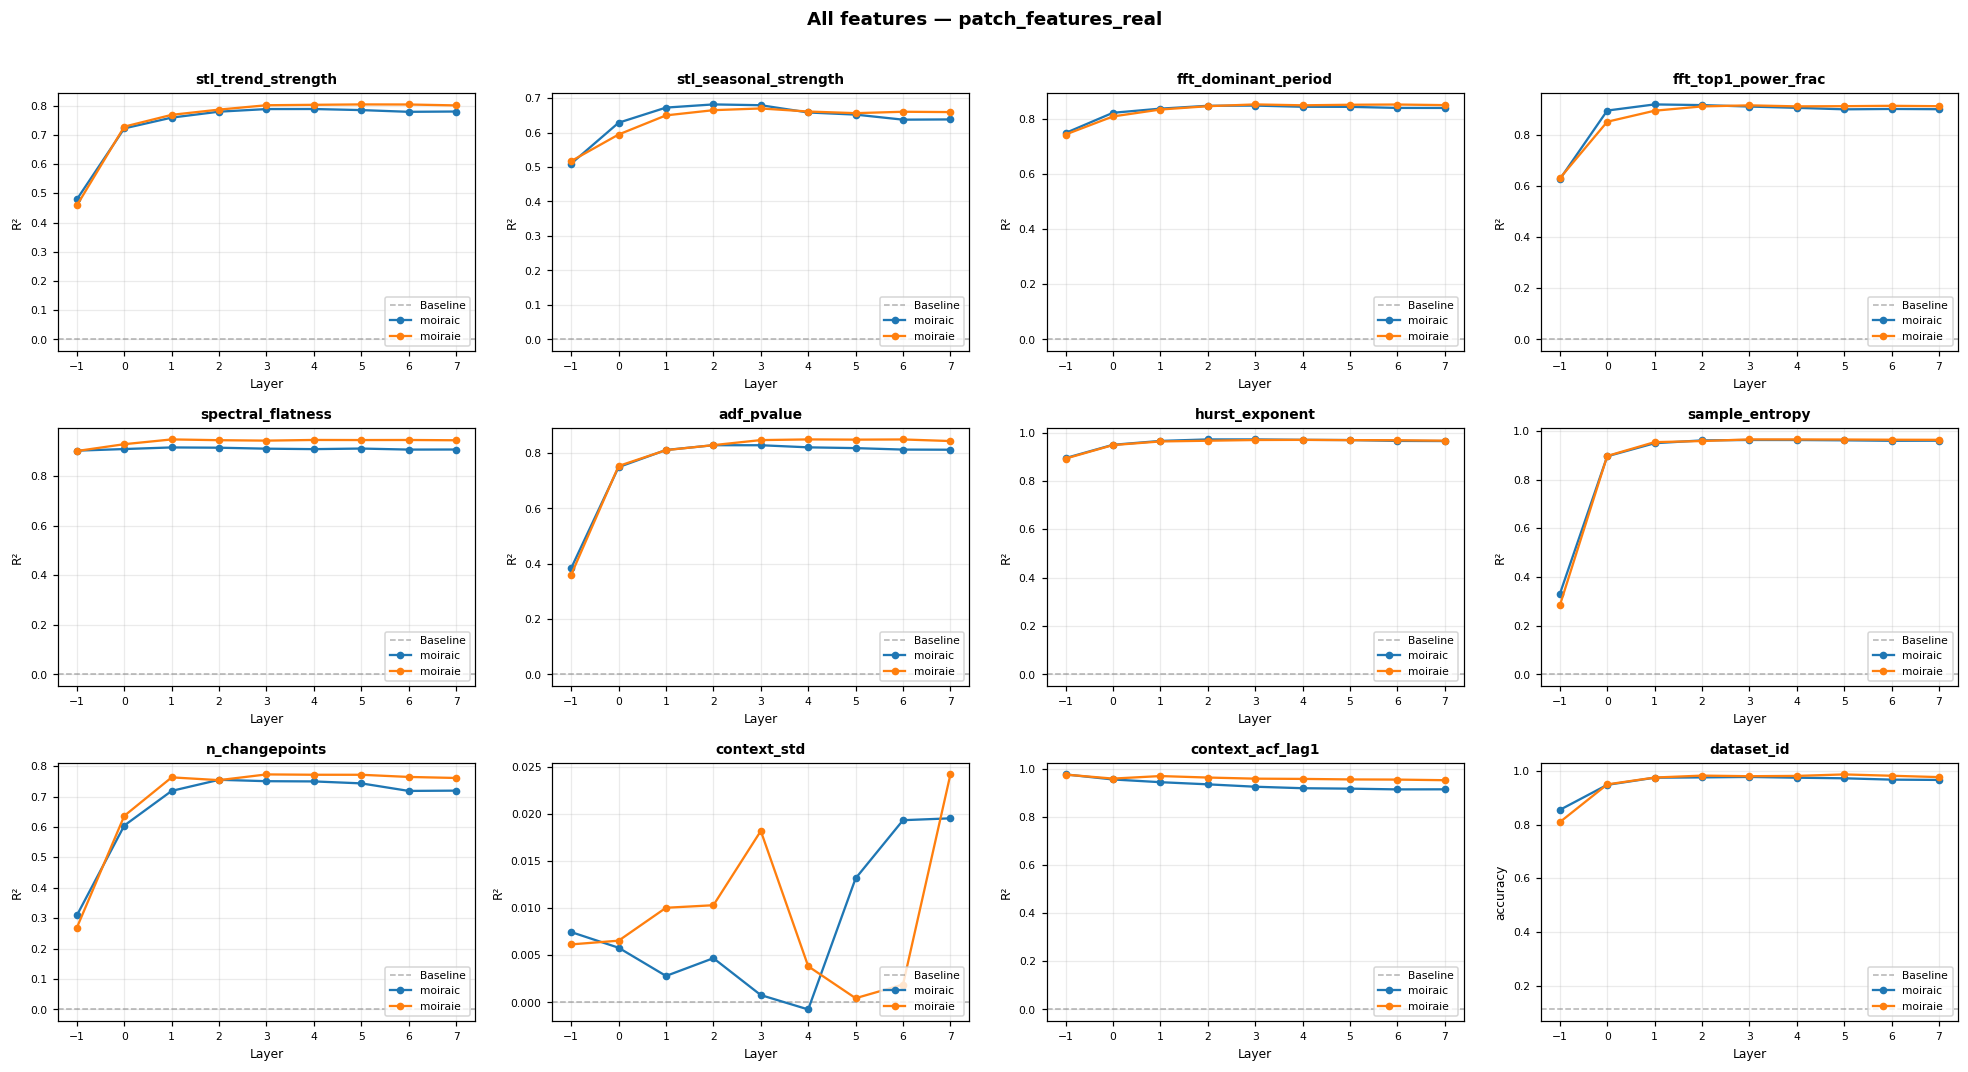

In [9]:
def plot_feature_overview(
    features: list[str],
    title: str = "",
    ncols: int = GRID_COLS,
) -> plt.Figure:
    nrows = math.ceil(len(features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)  # flatten regardless of shape

    for ax, feature in zip(axes, features):
        meta = feature_meta.get(feature, {"baseline": 0.0, "metric": "score"})
        baseline = meta.get("baseline", 0.0)
        metric = meta.get("metric", "score")

        ax.axhline(baseline, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="Baseline")

        for model, mode in all_model_modes:
            feat_data = standard_results[model][mode].get(feature)
            if feat_data is None:
                continue
            scores = [feat_data.get(l, float("nan")) for l in all_layers]
            ax.plot(
                all_layers, scores,
                marker="o", markersize=4,
                color=series_colors[(model, mode)],
                label=series_label(model, mode),
            )

        ax.set_title(feature, fontsize=9, fontweight="bold")
        ax.set_xlabel("Layer", fontsize=8)
        ax.set_ylabel(metric, fontsize=8)
        ax.set_xticks(all_layers)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=7, loc="lower right")

    # Hide unused axes
    for ax in axes[len(features):]:
        ax.set_visible(False)

    if title:
        fig.suptitle(title, fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    return fig


# Group features by probe type from metadata
def group_features_by_type(features: list[str]) -> dict[str, list[str]]:
    groups: dict[str, list[str]] = {}
    for feat in features:
        ftype = feature_meta.get(feat, {}).get("type", "other")
        groups.setdefault(ftype, []).append(feat)
    return groups


feature_groups = group_features_by_type(all_features_standard)
print("Feature groups:", {k: len(v) for k, v in feature_groups.items()})

# Overview: all features together
if all_features_standard:
    fig = plot_feature_overview(all_features_standard, title=f"All features — {EXPERIMENT}")
    _save(fig, f"probe_overview_{EXPERIMENT}")
    plt.show()

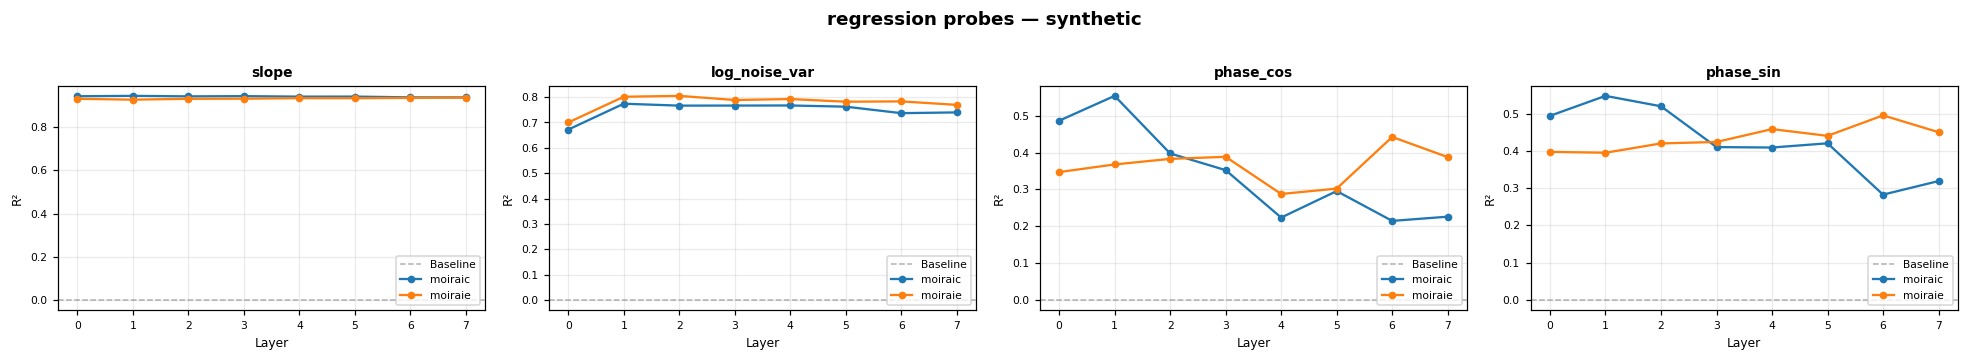

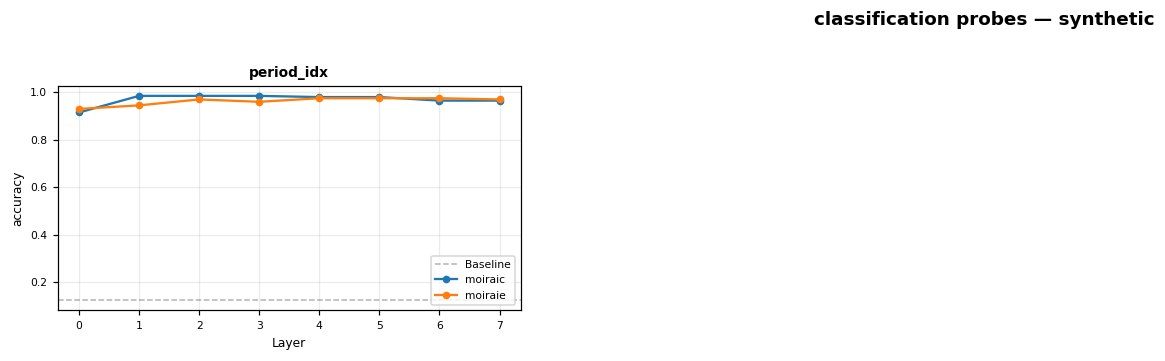

In [ ]:
# ── Per-type subplots ─────────────────────────────────────────────────────────
for ftype, features in feature_groups.items():
    if not features:
        continue
    fig = plot_feature_overview(features, title=f"{ftype} probes — {EXPERIMENT}")
    _save(fig, f"probe_{ftype}_{EXPERIMENT}")
    plt.show()

## Per-patch heatmaps

Shows probe score as a function of both **layer** (y-axis) and **patch position within context** (x-axis).  
Only available for models with `*_per_patch.json` results.

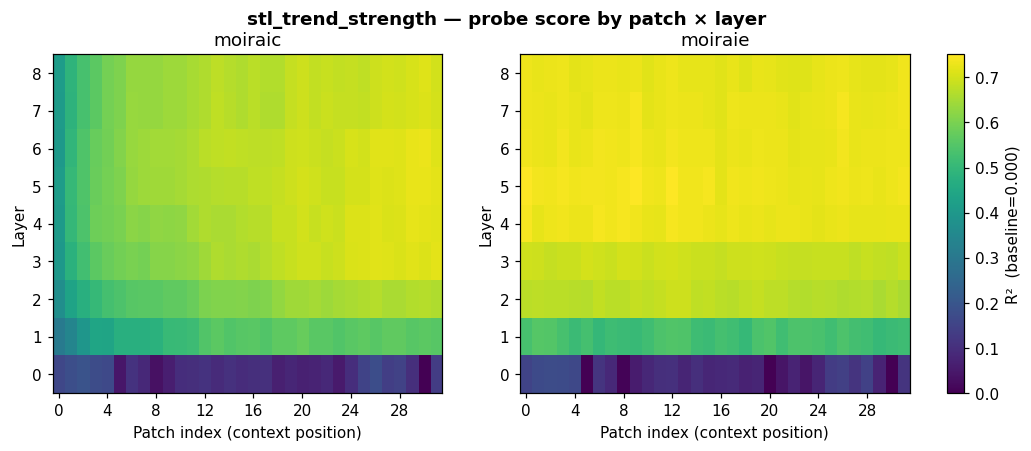

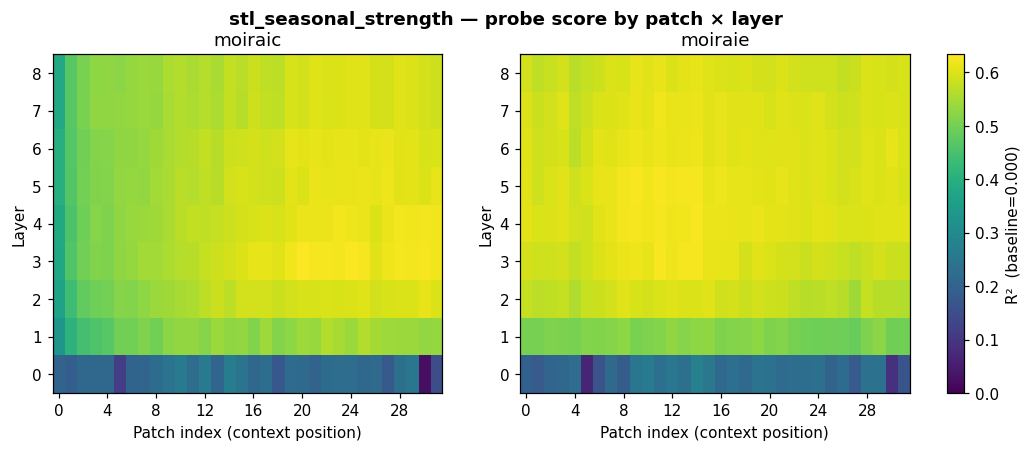

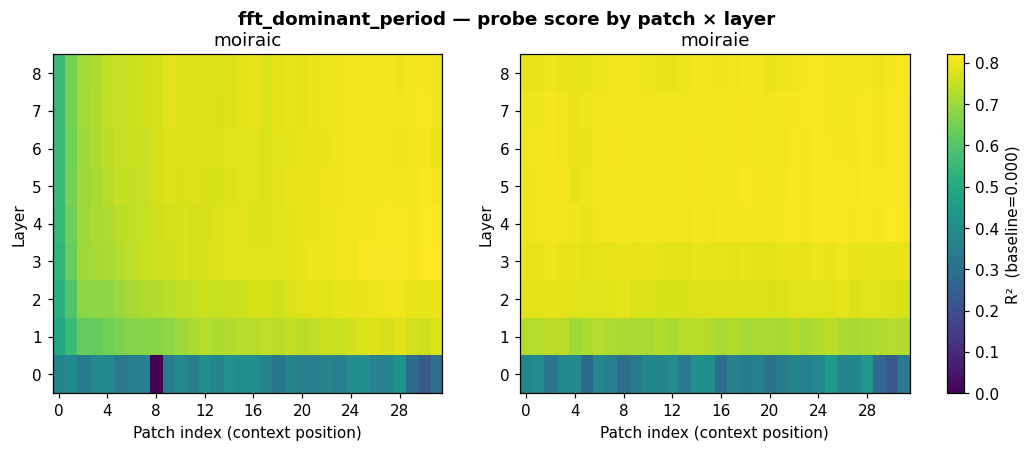

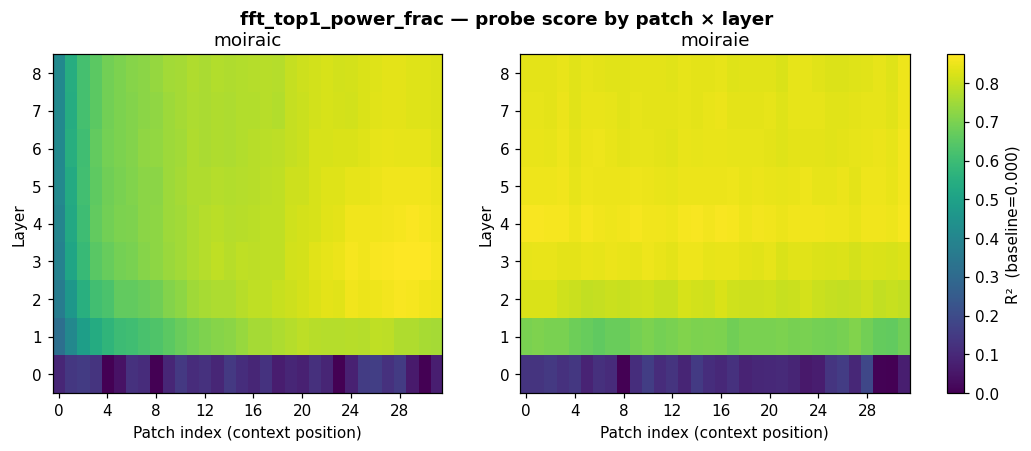

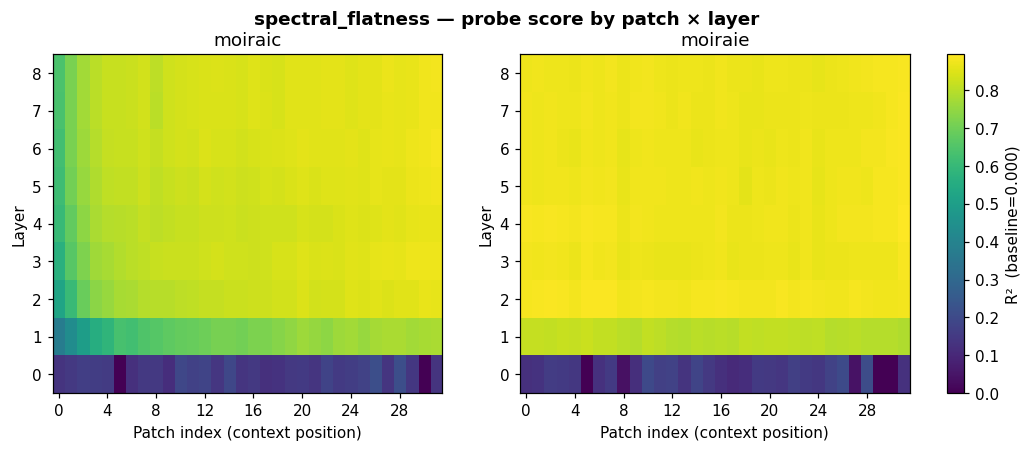

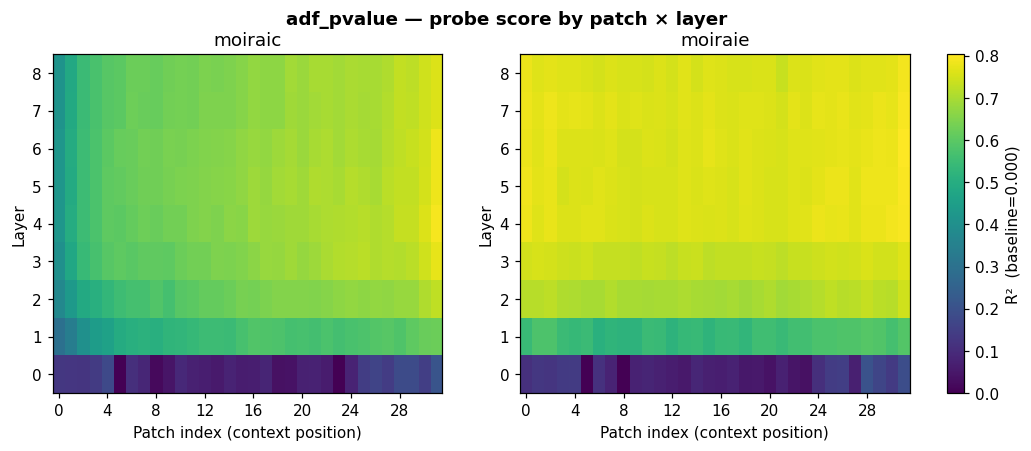

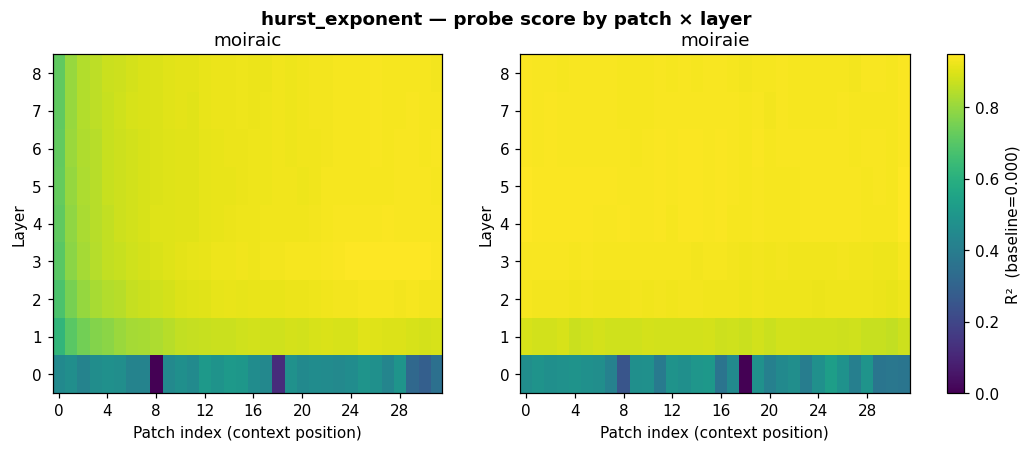

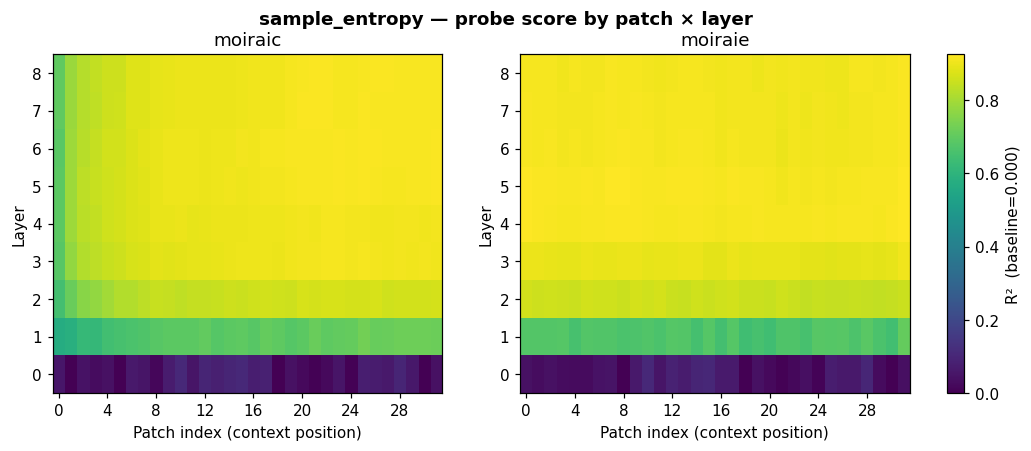

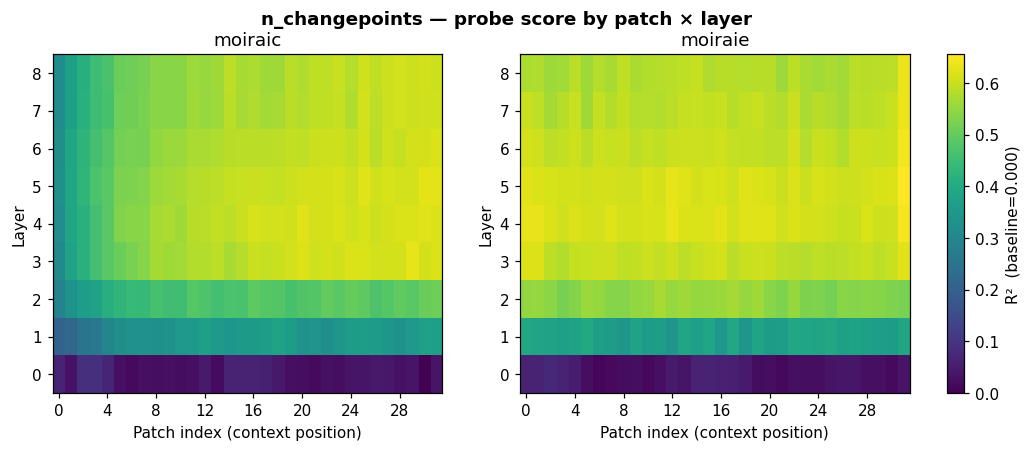

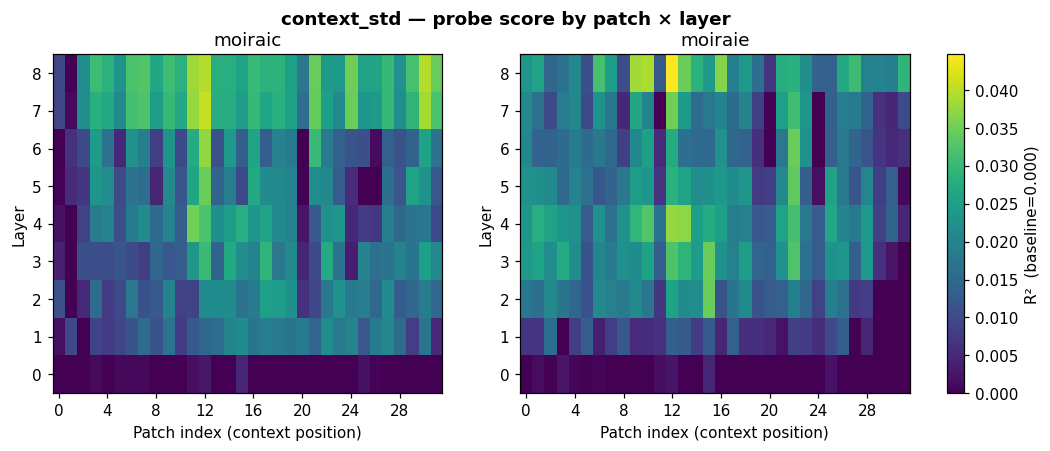

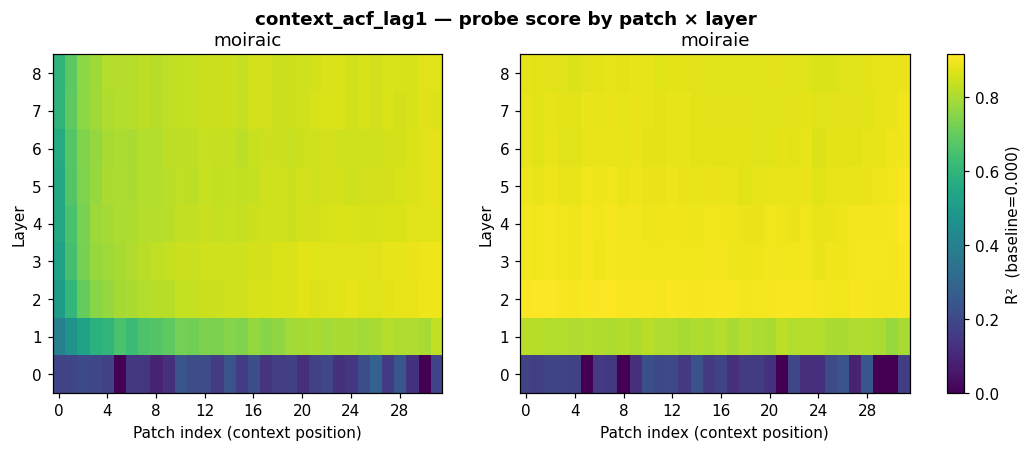

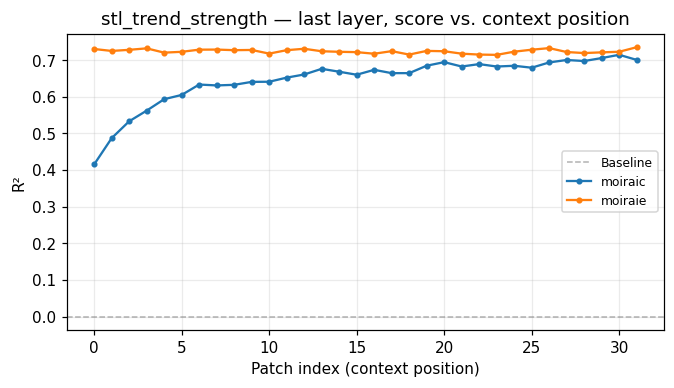

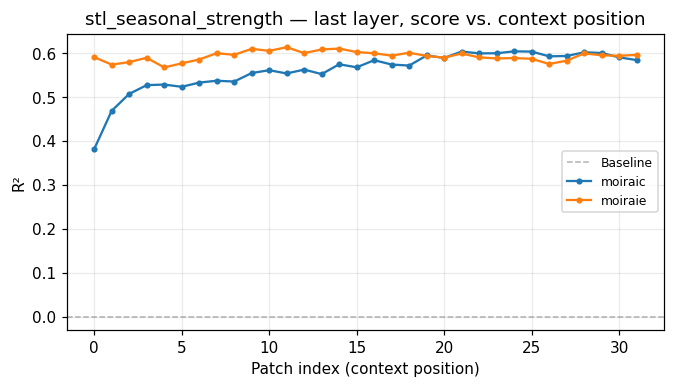

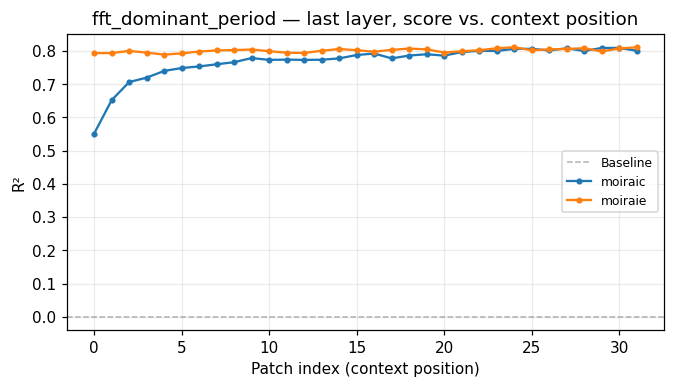

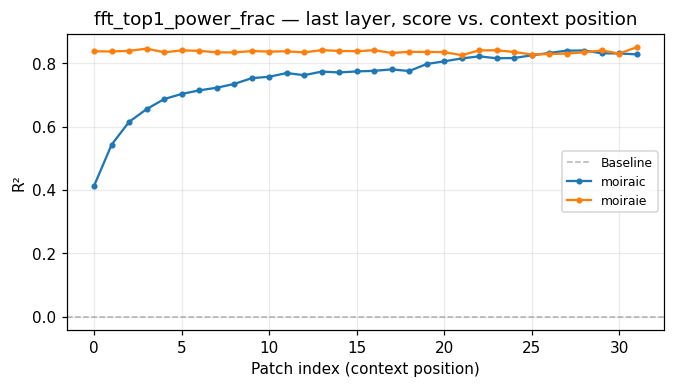

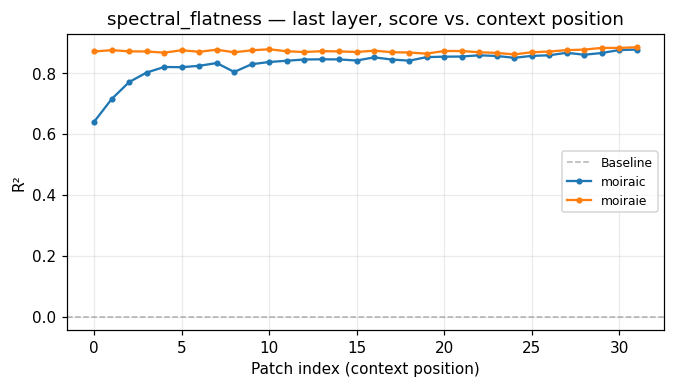

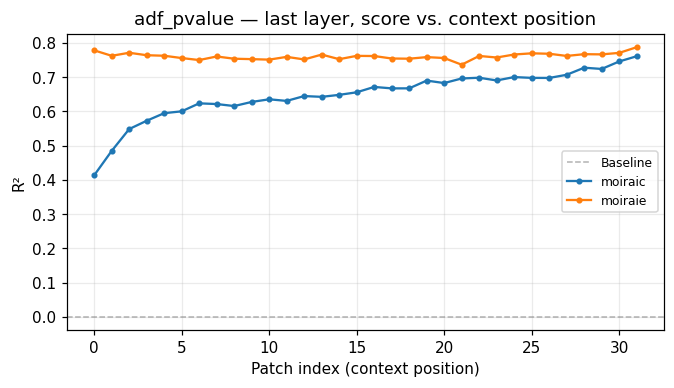

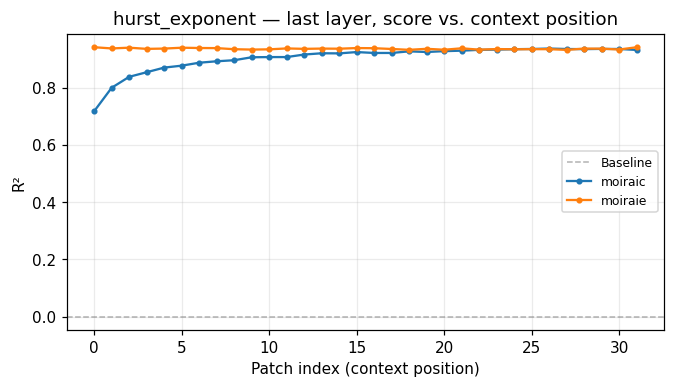

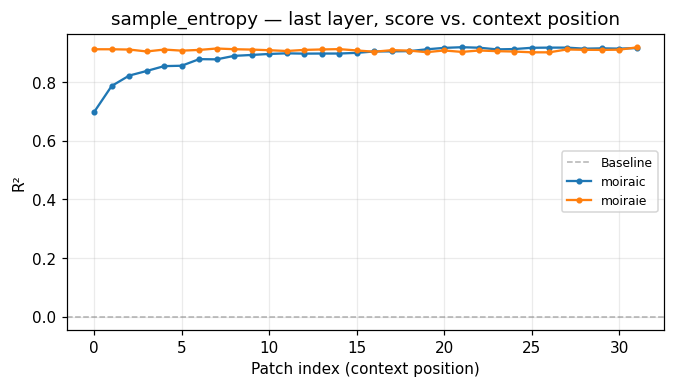

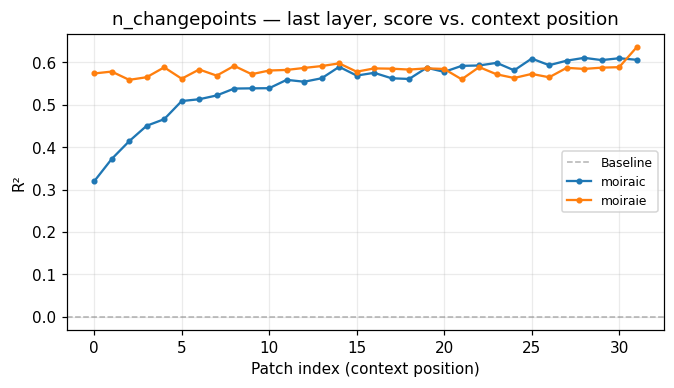

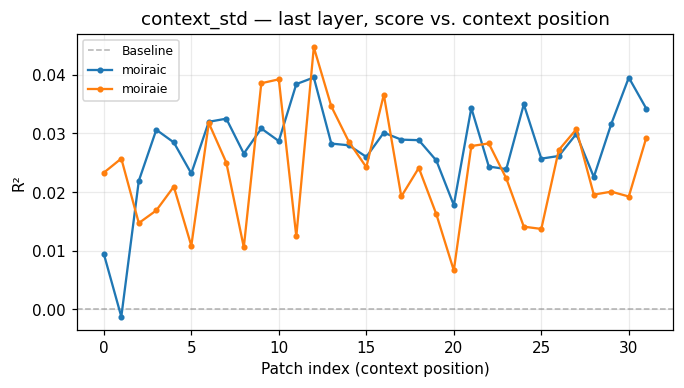

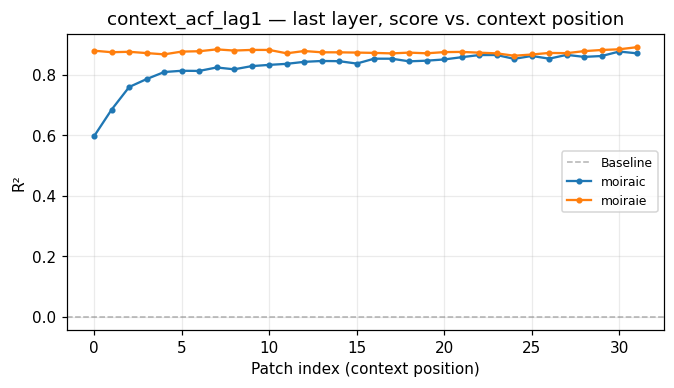

In [10]:
if not per_patch_paths:
    print("No per-patch results found in", results_dir)
else:
    per_patch_results: dict[str, dict[str, dict[int, dict[int, float]]]] = {
        stem: load_per_patch(path) for stem, path in per_patch_paths.items()
    }

    pp_features = list(dict.fromkeys(
        feat
        for data in per_patch_results.values()
        for feat in data
    ))
    if FEATURES_FILTER:
        pp_features = [f for f in pp_features if f in FEATURES_FILTER]

    pp_models = list(per_patch_results.keys())

    for feature in pp_features:
        meta = feature_meta.get(feature, {"baseline": 0.0, "metric": "score"})
        baseline = meta.get("baseline", 0.0)
        metric = meta.get("metric", "score")

        # Build grids per model
        grids = {
            model: _scores_to_grid(per_patch_results[model][feature])
            for model in pp_models
            if feature in per_patch_results[model]
        }
        if not grids:
            continue

        # Shared color scale across models
        vmin = baseline
        vmax = max(np.nanmax(g) for g in grids.values())
        vmax = max(vmax, baseline + 1e-3)

        n_models = len(grids)
        fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 4), squeeze=False)
        im = None
        for ax, model in zip(axes[0], grids):
            grid = grids[model]  # [layers, patches]
            im = ax.imshow(
                grid, aspect="auto", origin="lower",
                cmap="viridis", vmin=vmin, vmax=vmax, interpolation="nearest",
            )
            n_patches = grid.shape[1]
            ax.set_xlabel("Patch index (context position)")
            ax.set_ylabel("Layer")
            ax.set_title(_model_label(model))
            ax.set_xticks(range(0, n_patches, max(1, n_patches // 8)))
            ax.set_yticks(range(grid.shape[0]))

        if im is not None:
            cb = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            cb.set_label(f"{metric}  (baseline={baseline:.3f})")

        fig.suptitle(f"{feature} — probe score by patch × layer", fontweight="bold")
        # plt.tight_layout()
        _save(fig, f"probe_patch_{feature}_{EXPERIMENT}")
        plt.show()

    # ── Last-layer slice: score vs. patch position ────────────────────────────
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    model_colors_pp = {m: prop_cycle[i % len(prop_cycle)] for i, m in enumerate(pp_models)}

    for feature in pp_features:
        meta = feature_meta.get(feature, {"baseline": 0.0, "metric": "score"})
        baseline = meta.get("baseline", 0.0)
        metric = meta.get("metric", "score")

        fig, ax = plt.subplots(figsize=(7, 3.5))
        ax.axhline(baseline, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="Baseline")

        for model in pp_models:
            if feature not in per_patch_results[model]:
                continue
            grid = _scores_to_grid(per_patch_results[model][feature])
            ax.plot(
                range(grid.shape[1]), grid[-1, :],
                marker="o", markersize=3,
                color=model_colors_pp[model],
                label=_model_label(model),
            )

        ax.set_xlabel("Patch index (context position)")
        ax.set_ylabel(metric)
        ax.set_title(f"{feature} — last layer, score vs. context position")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)
        # plt.tight_layout()
        _save(fig, f"probe_patch_slice_{feature}_{EXPERIMENT}")
        plt.show()

## Per-patch **local** feature probes  (EXP-001)

Loaded from `*_patch_features.json`. Unlike the broadcast-label per-patch probes above, the
label here is computed **per patch** from each patch's local content, so the probe at position
*k* predicts what is happening *in patch k*.

Three views:
1. **Score vs layer** (aggregated over patch positions) — the key plot. Layer `-1` is the
   post-projection / pre-attention **embedding baseline**: local stats should already be high
   there ("free"), relative features should rise with depth. Solid = mean over patches,
   dashed = best patch.
2. **Layer × patch heatmaps** — where (depth × position) each local feature becomes decodable.
3. **Score vs patch position** (last layer) — uniform for the bidirectional encoder, a causal
   ramp for the decoder.

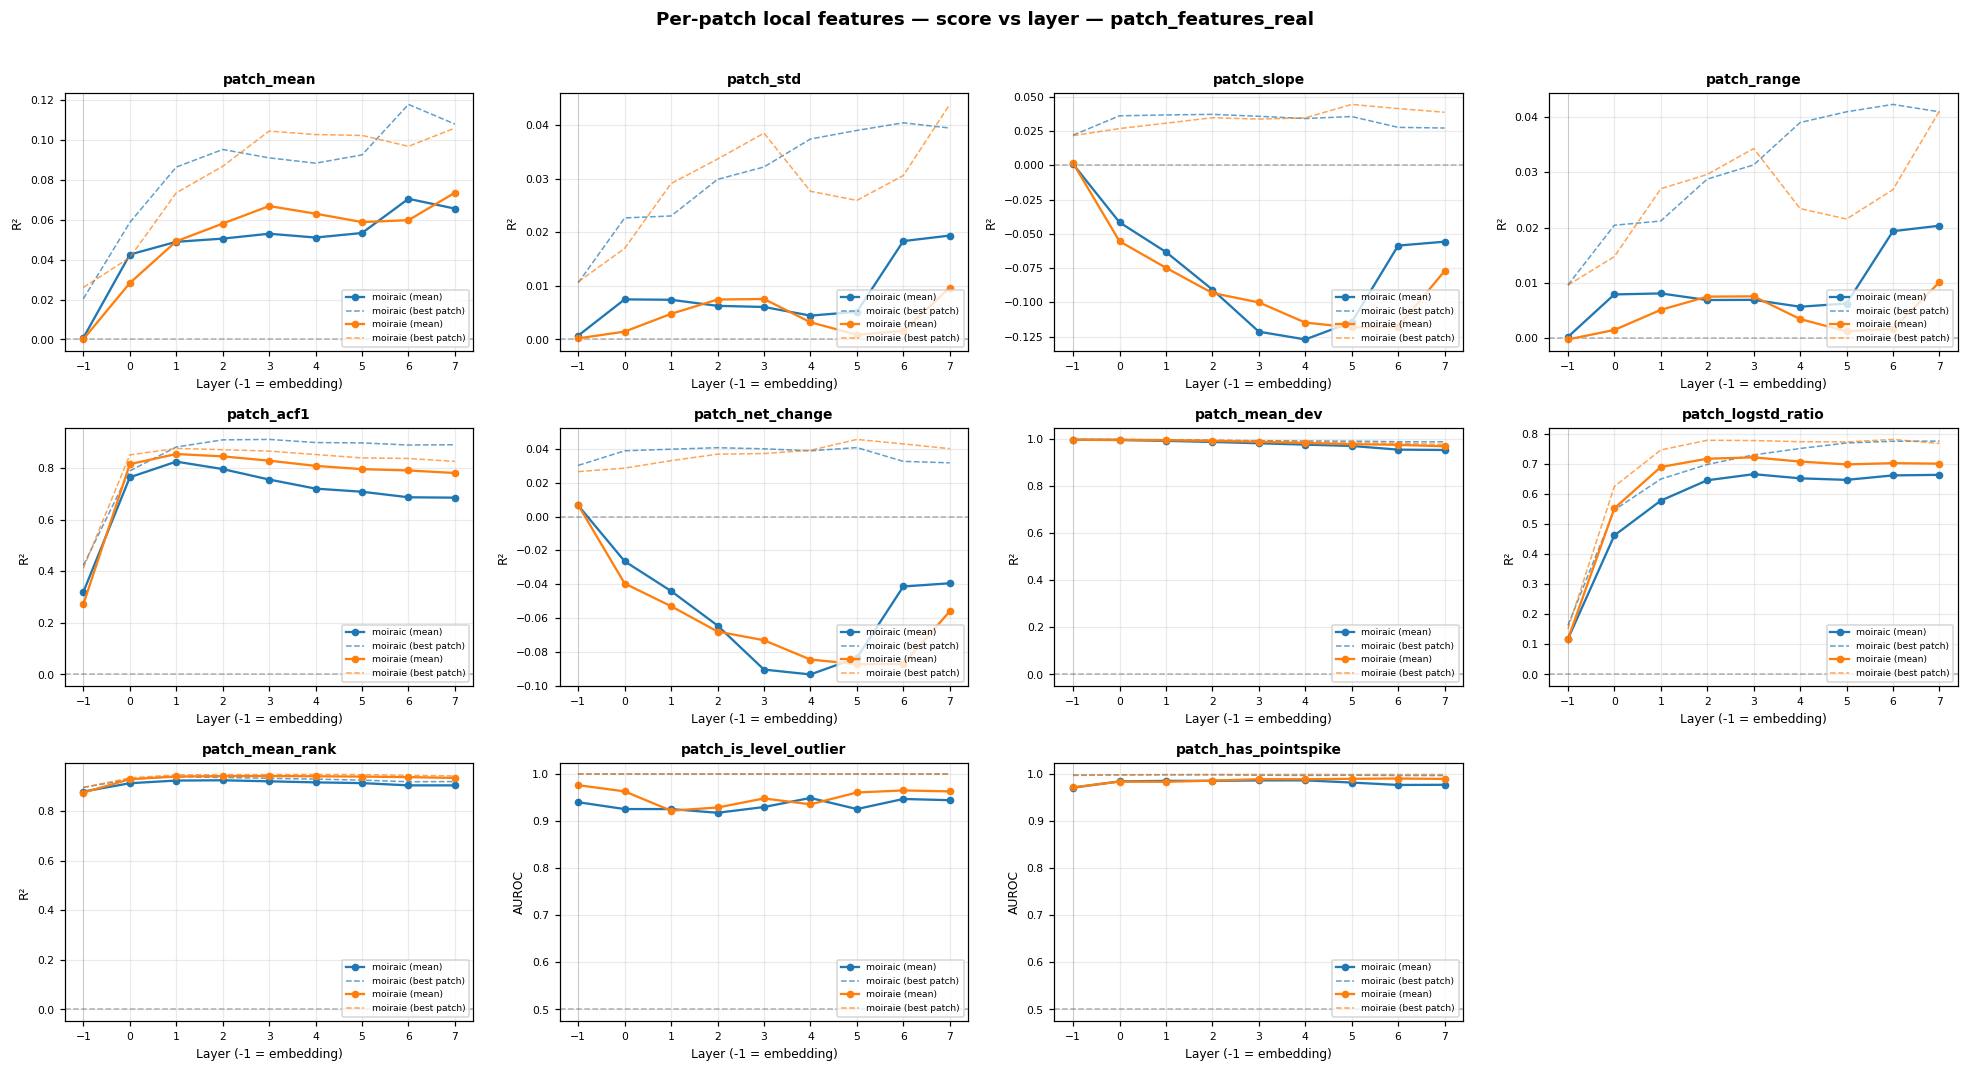

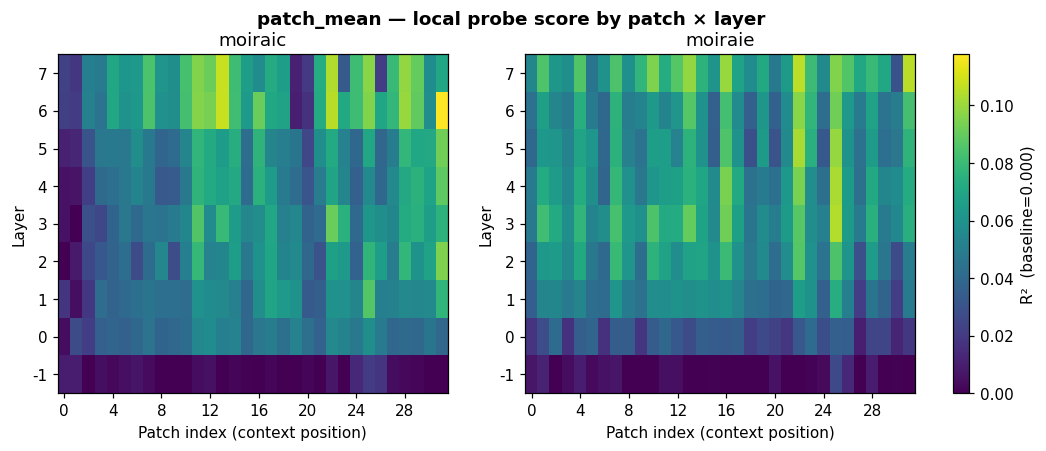

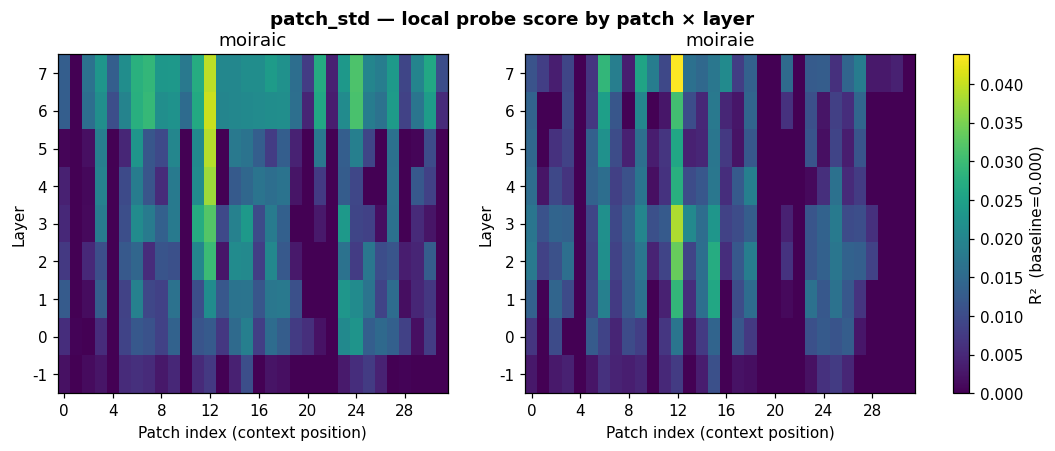

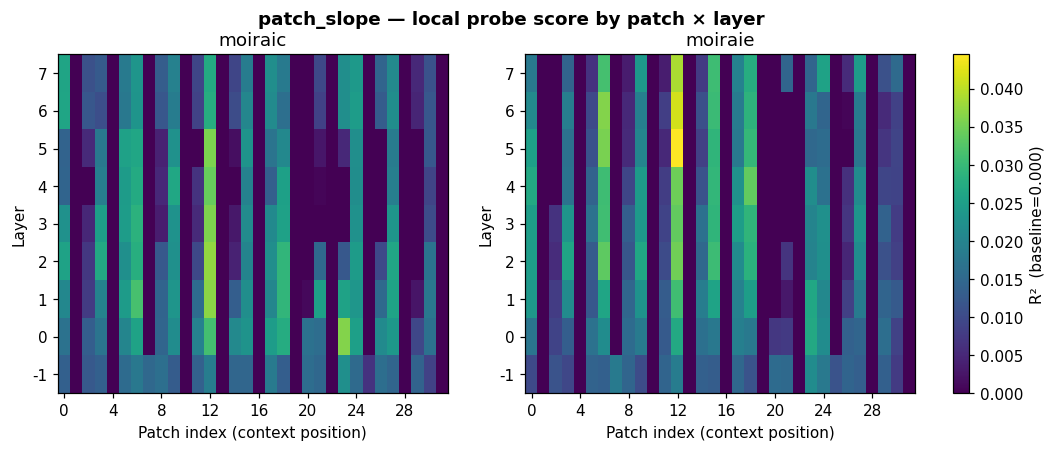

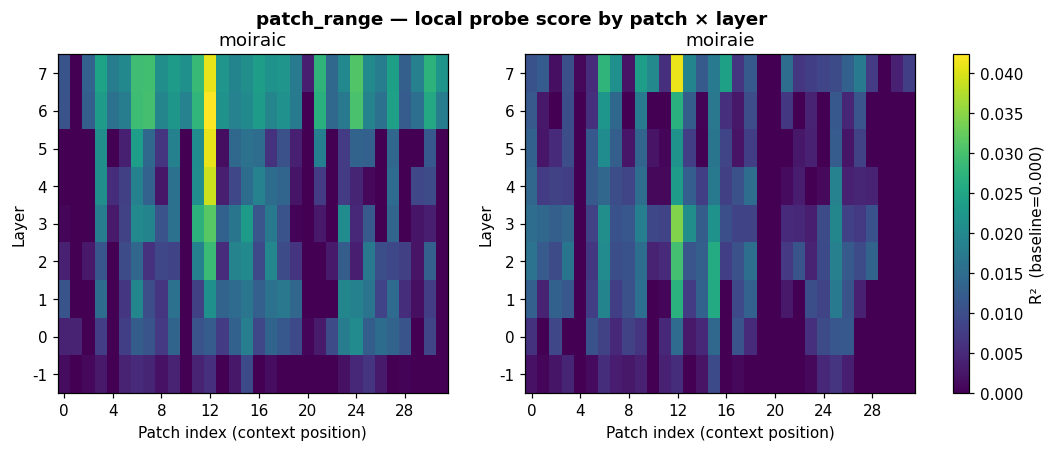

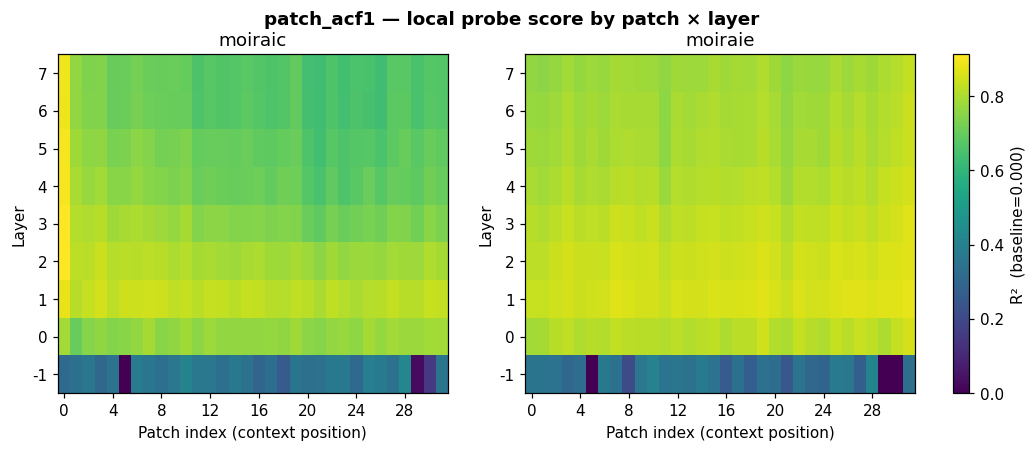

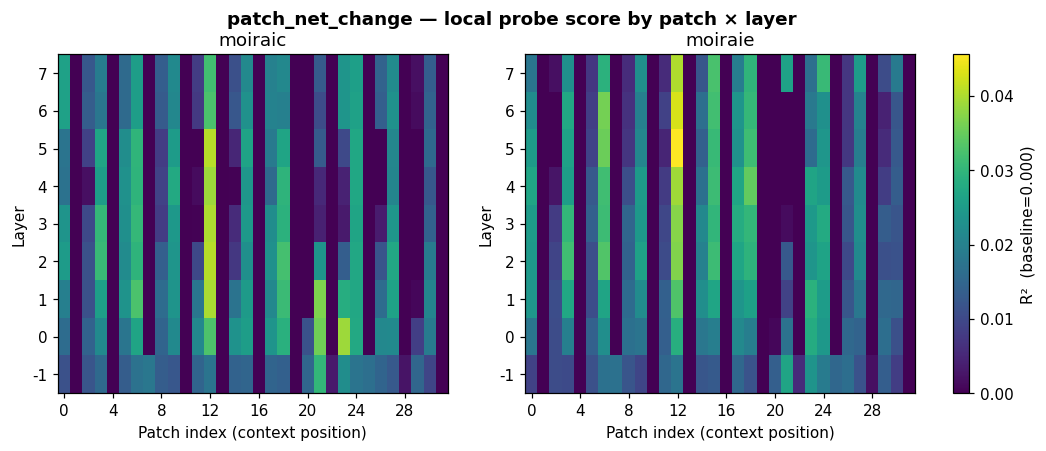

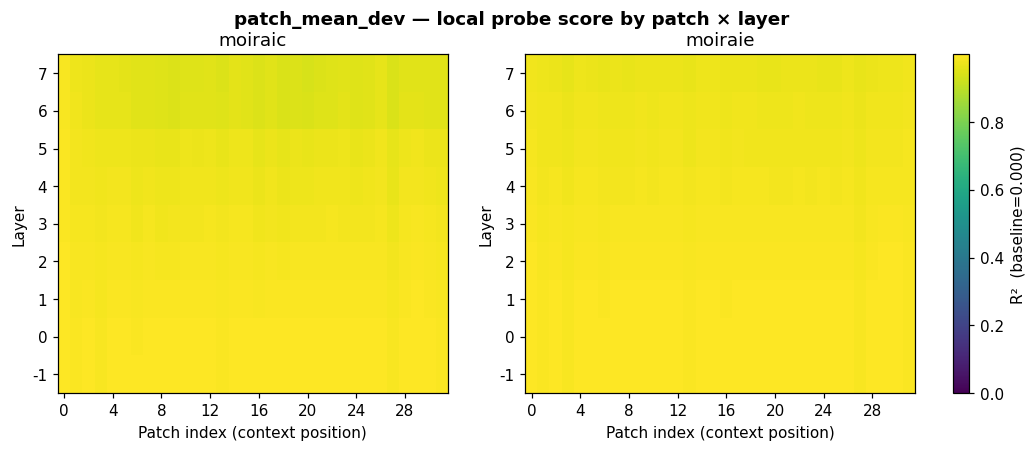

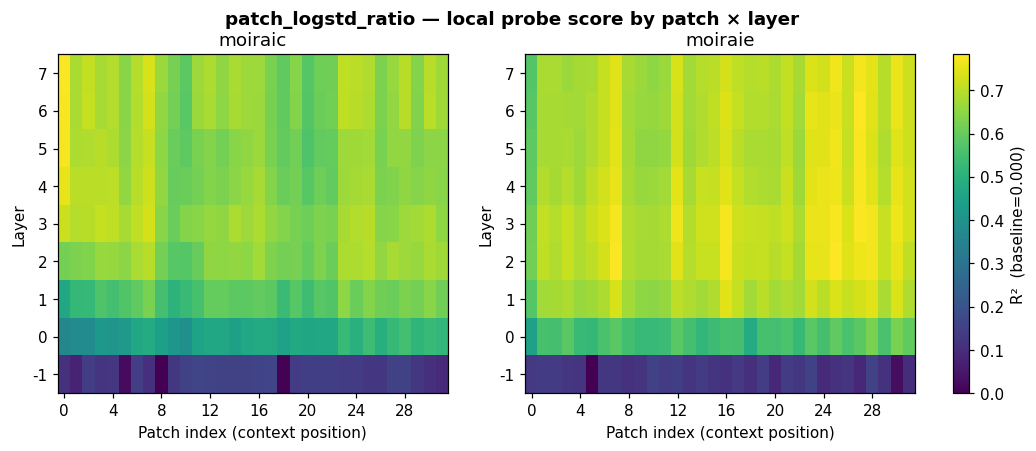

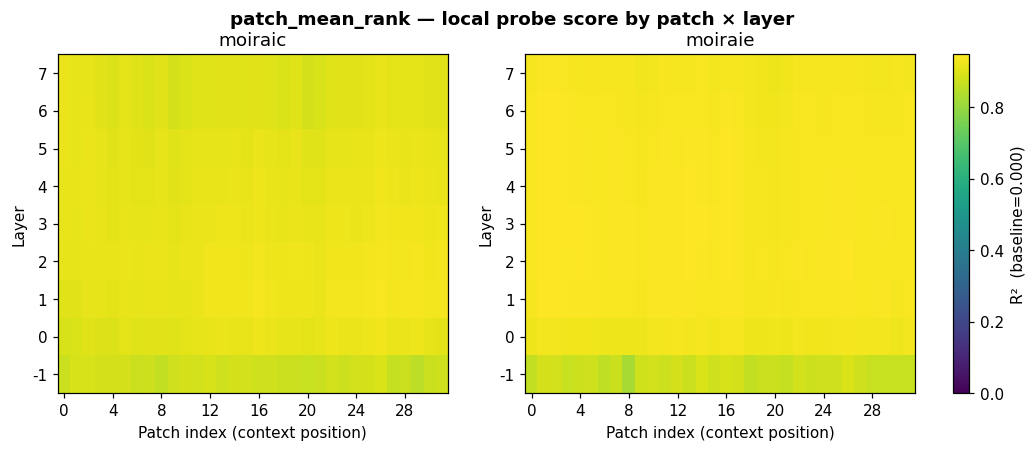

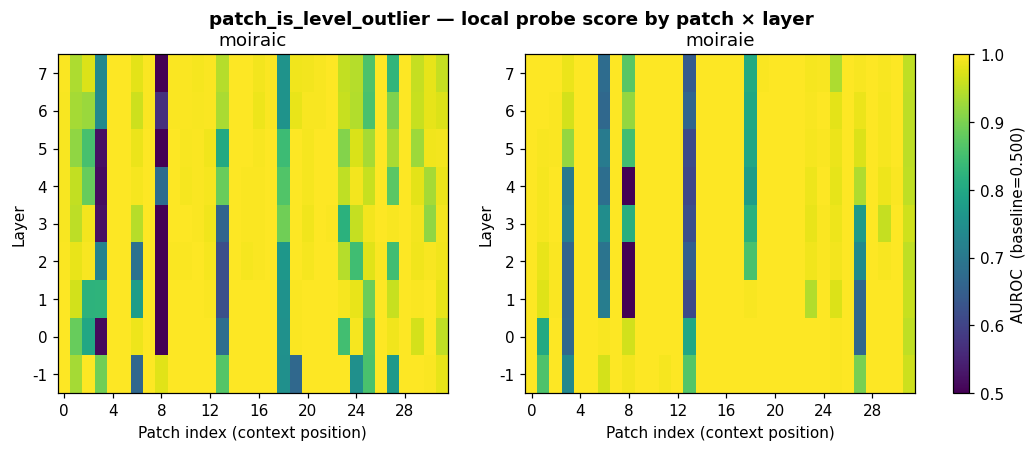

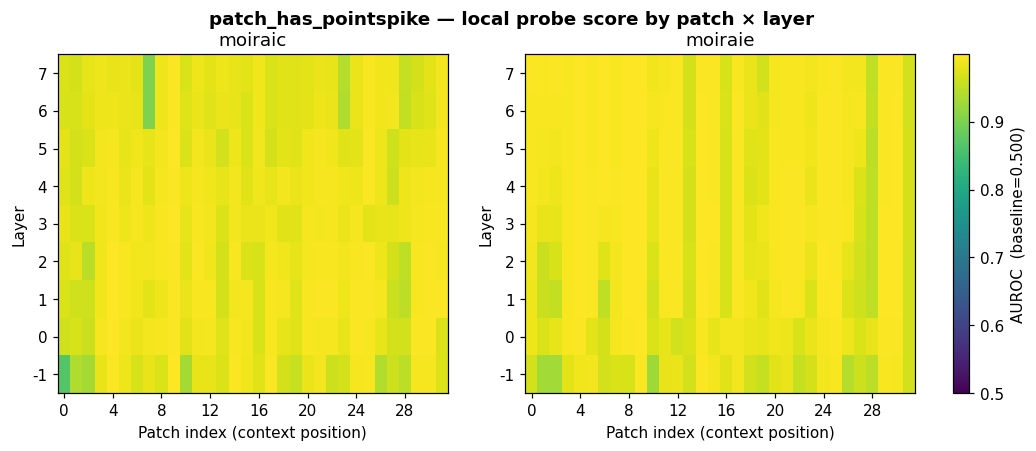

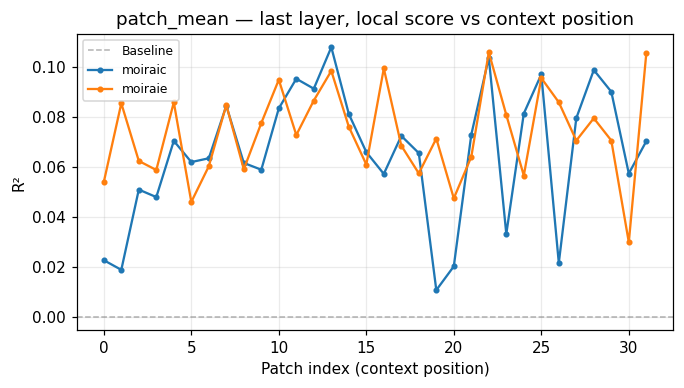

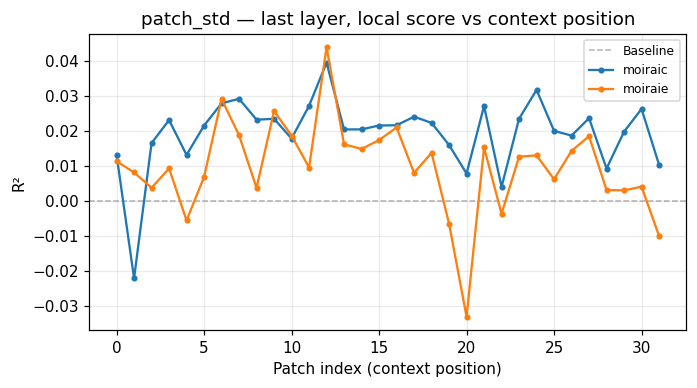

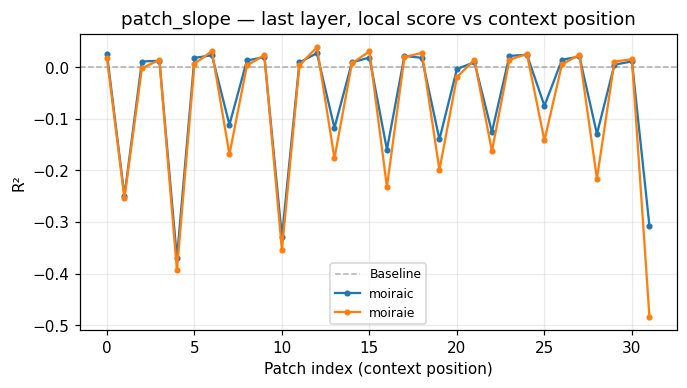

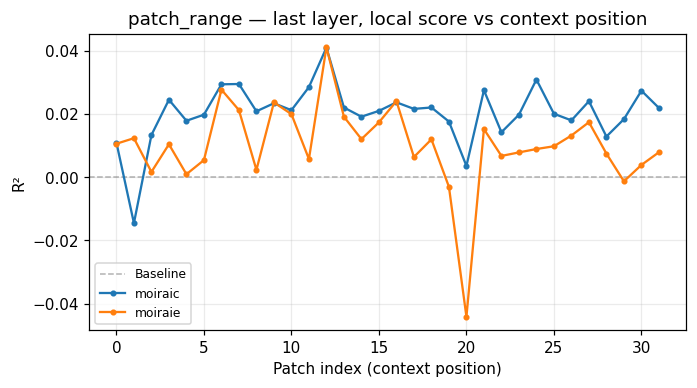

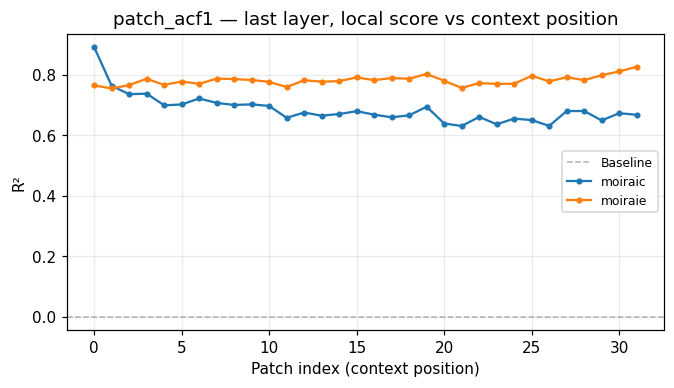

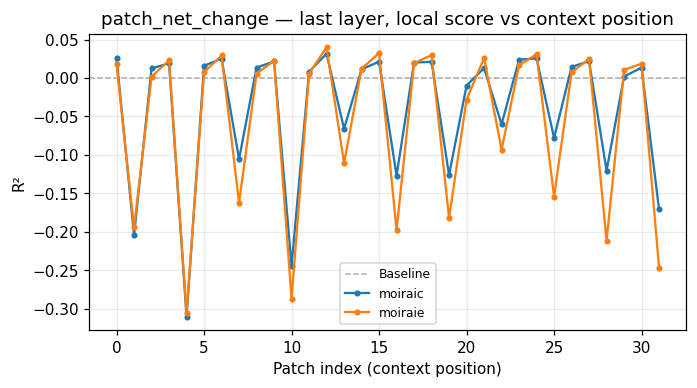

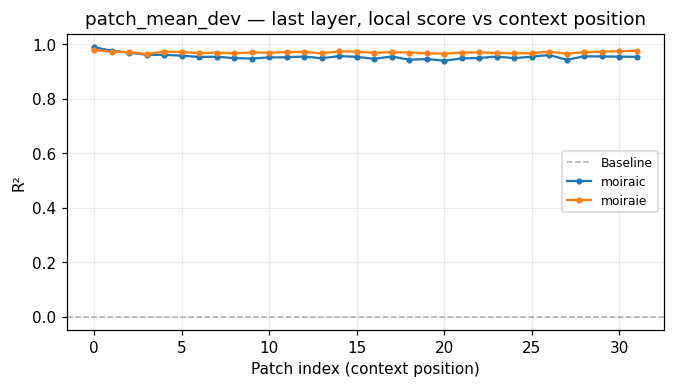

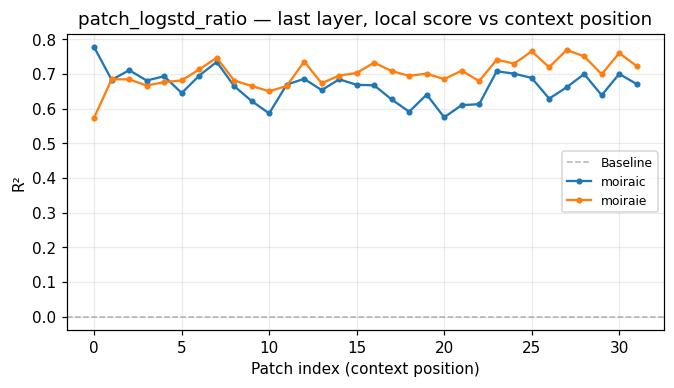

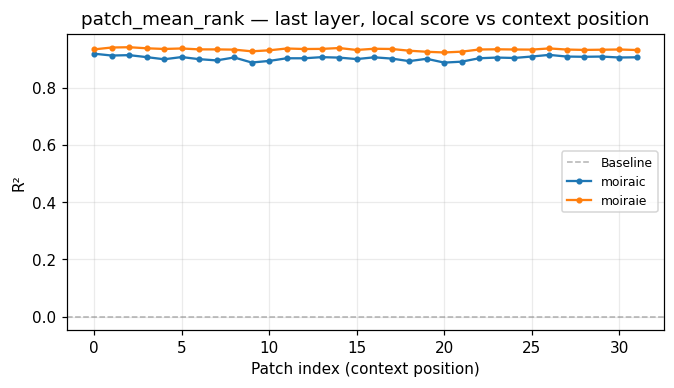

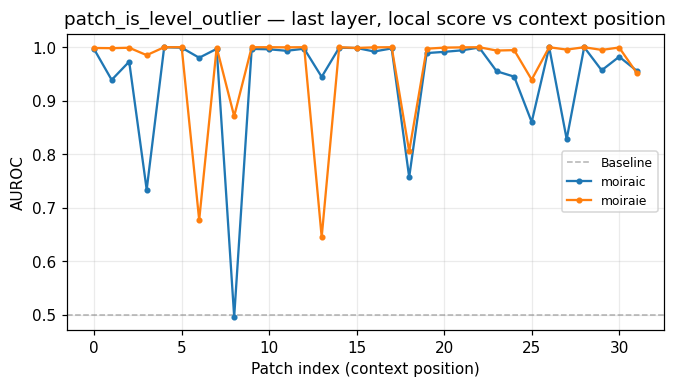

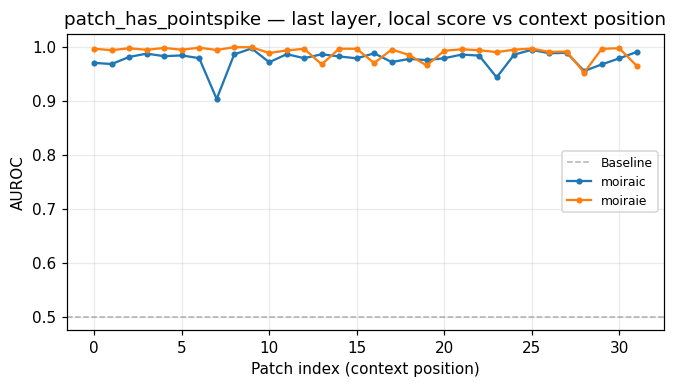

In [11]:
if not patch_feature_paths:
    print("No patch-feature results found in", results_dir)
else:
    patch_feat_results: dict[str, dict[str, dict[int, dict[int, float]]]] = {
        stem: load_per_patch(path) for stem, path in patch_feature_paths.items()
    }
    pf_models = list(patch_feat_results)
    pf_features = list(dict.fromkeys(
        feat for data in patch_feat_results.values() for feat in data
    ))
    if FEATURES_FILTER:
        pf_features = [f for f in pf_features if f in FEATURES_FILTER]

    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    pf_colors = {m: prop_cycle[i % len(prop_cycle)] for i, m in enumerate(pf_models)}

    def _pf_layers(feat: str, model: str) -> list[int]:
        return sorted(patch_feat_results[model][feat])

    # ── (1) Score vs layer, aggregated over patch positions ───────────────────
    # Solid = mean over patches, dashed = best patch. Layer -1 = embedding baseline.
    ncols = GRID_COLS
    nrows = math.ceil(len(pf_features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, feature in zip(axes, pf_features):
        meta = feature_meta.get(feature, {"baseline": 0.0, "metric": "score"})
        baseline, metric = meta.get("baseline", 0.0), meta.get("metric", "score")
        ax.axhline(baseline, color="gray", ls="--", lw=1, alpha=0.6)
        for model in pf_models:
            if feature not in patch_feat_results[model]:
                continue
            grid = _scores_to_grid(patch_feat_results[model][feature])  # [layers, patches]
            layers = _pf_layers(feature, model)
            with np.errstate(all="ignore"):
                mean_s = np.nanmean(grid, axis=1)
                max_s = np.nanmax(grid, axis=1)
            ax.plot(layers, mean_s, marker="o", ms=4, color=pf_colors[model],
                    label=f"{_model_label(model)} (mean)")
            ax.plot(layers, max_s, marker="", ls="--", lw=1, color=pf_colors[model], alpha=0.7,
                    label=f"{_model_label(model)} (best patch)")
        ax.axvline(-1, color="k", lw=0.6, alpha=0.15)
        ax.set_title(feature, fontsize=9, fontweight="bold")
        ax.set_xlabel("Layer (-1 = embedding)", fontsize=8)
        ax.set_ylabel(metric, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=6, loc="lower right")
    for ax in axes[len(pf_features):]:
        ax.set_visible(False)
    fig.suptitle(f"Per-patch local features — score vs layer — {EXPERIMENT}",
                 fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    _save(fig, f"patchfeat_by_layer_{EXPERIMENT.replace('/', '_')}")
    plt.show()

    # ── (2) Layer × patch heatmaps ────────────────────────────────────────────
    for feature in pf_features:
        meta = feature_meta.get(feature, {"baseline": 0.0, "metric": "score"})
        baseline, metric = meta.get("baseline", 0.0), meta.get("metric", "score")
        grids = {
            m: _scores_to_grid(patch_feat_results[m][feature])
            for m in pf_models if feature in patch_feat_results[m]
        }
        if not grids:
            continue
        finite_max = [np.nanmax(g) for g in grids.values() if np.isfinite(g).any()]
        vmax = max(finite_max) if finite_max else baseline + 1e-3
        vmax = max(vmax, baseline + 1e-3)
        layers0 = _pf_layers(feature, next(iter(grids)))

        n_models = len(grids)
        fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 4), squeeze=False)
        im = None
        for ax, model in zip(axes[0], grids):
            grid = grids[model]
            im = ax.imshow(grid, aspect="auto", origin="lower", cmap="viridis",
                           vmin=baseline, vmax=vmax, interpolation="nearest")
            n_patches = grid.shape[1]
            ax.set_xlabel("Patch index (context position)")
            ax.set_ylabel("Layer")
            ax.set_yticks(range(len(layers0)))
            ax.set_yticklabels(layers0)
            ax.set_xticks(range(0, n_patches, max(1, n_patches // 8)))
            ax.set_title(_model_label(model))
        if im is not None:
            cb = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            cb.set_label(f"{metric}  (baseline={baseline:.3f})")
        fig.suptitle(f"{feature} — local probe score by patch × layer", fontweight="bold")
        _save(fig, f"patchfeat_heat_{feature}_{EXPERIMENT.replace('/', '_')}")
        plt.show()

    # ── (3) Last-layer slice: score vs patch position ─────────────────────────
    for feature in pf_features:
        meta = feature_meta.get(feature, {"baseline": 0.0, "metric": "score"})
        baseline, metric = meta.get("baseline", 0.0), meta.get("metric", "score")
        fig, ax = plt.subplots(figsize=(7, 3.5))
        ax.axhline(baseline, color="gray", ls="--", lw=1, alpha=0.6, label="Baseline")
        for model in pf_models:
            if feature not in patch_feat_results[model]:
                continue
            grid = _scores_to_grid(patch_feat_results[model][feature])
            ax.plot(range(grid.shape[1]), grid[-1, :], marker="o", ms=3,
                    color=pf_colors[model], label=_model_label(model))
        ax.set_xlabel("Patch index (context position)")
        ax.set_ylabel(metric)
        ax.set_title(f"{feature} — last layer, local score vs context position")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)
        _save(fig, f"patchfeat_slice_{feature}_{EXPERIMENT.replace('/', '_')}")
        plt.show()

## Compositional probes

Each entry is a feature **pair** (`A→B`).  
- **atomic**: probe trained on A alone  
- **pair**: probe trained on joint (A, B) representation  
- **delta**: atomic − pair (how much A's representation degrades when B is present)

In [ ]:
if not compositional_paths:
    print("No compositional results found in", results_dir)
else:
    comp_results: dict[str, dict[str, dict[str, dict[int, dict[str, float]]]]] = {
        stem: load_compositional(path, PROBE_MODE)
        for stem, path in compositional_paths.items()
    }

    comp_models = list(comp_results.keys())
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    comp_model_colors = {m: prop_cycle[i % len(prop_cycle)] for i, m in enumerate(comp_models)}

    # Gather all pairs across all models/modes
    all_pairs: list[str] = list(dict.fromkeys(
        pair
        for model_data in comp_results.values()
        for mode_data in model_data.values()
        for pair in mode_data
    ))

    COMP_METRIC = ["atomic", "pair", "delta"]

    for pair in all_pairs:
        # Determine all layers present for this pair
        pair_layers = sorted({
            layer
            for model_data in comp_results.values()
            for mode_data in model_data.values()
            for layer in mode_data.get(pair, {})
        })

        fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=False)
        for ax, metric in zip(axes, COMP_METRIC):
            for model, model_data in comp_results.items():
                for mode, mode_data in model_data.items():
                    if pair not in mode_data:
                        continue
                    scores = [mode_data[pair].get(l, {}).get(metric, float("nan")) for l in pair_layers]
                    label = series_label(model, mode)
                    ax.plot(
                        pair_layers, scores,
                        marker="o", markersize=4,
                        color=comp_model_colors[model],
                        label=label,
                    )
            ax.set_title(metric)
            ax.set_xlabel("Layer")
            ax.set_ylabel("Score")
            ax.set_xticks(pair_layers)
            ax.grid(True, alpha=0.25)
            ax.legend(fontsize=7)

        fig.suptitle(f"Compositional probe: {pair}", fontweight="bold")
        plt.tight_layout()
        safe_pair = pair.replace("→", "_to_").replace("/", "_")
        _save(fig, f"probe_comp_{safe_pair}_{EXPERIMENT}")
        plt.show()

    # ── Delta heatmap: all pairs × all layers for each model ─────────────────
    for model, model_data in comp_results.items():
        for mode, mode_data in model_data.items():
            pairs_present = [p for p in all_pairs if p in mode_data]
            if not pairs_present:
                continue

            pair_layers_all = sorted({
                layer for p in pairs_present for layer in mode_data[p]
            })

            delta_matrix = np.array([
                [mode_data[p].get(l, {}).get("delta", float("nan")) for l in pair_layers_all]
                for p in pairs_present
            ])

            fig, ax = plt.subplots(figsize=(max(6, len(pair_layers_all)), max(4, len(pairs_present) * 0.35)))
            im = ax.imshow(delta_matrix, aspect="auto", cmap="RdBu_r",
                           vmin=-np.nanmax(np.abs(delta_matrix)),
                           vmax= np.nanmax(np.abs(delta_matrix)),
                           interpolation="nearest")
            ax.set_xticks(range(len(pair_layers_all)))
            ax.set_xticklabels(pair_layers_all)
            ax.set_yticks(range(len(pairs_present)))
            ax.set_yticklabels(pairs_present, fontsize=7)
            ax.set_xlabel("Layer")
            fig.colorbar(im, ax=ax, label="delta (atomic − pair)")
            title = f"Delta heatmap — {_model_label(model)}"
            if mode != "default":
                title += f" ({mode})"
            ax.set_title(title, fontweight="bold")
            plt.tight_layout()
            _save(fig, f"probe_comp_delta_heatmap_{model}_{EXPERIMENT}")
            plt.show()

No compositional results found in ../results/real


## Summary table

Best score per feature across all layers and models.

In [ ]:
import pandas as pd

rows = []
for feature in all_features_standard:
    meta = feature_meta.get(feature, {})
    row = {
        "feature": feature,
        "type": meta.get("type", "?"),
        "metric": meta.get("metric", "score"),
        "baseline": meta.get("baseline", float("nan")),
    }
    for model, mode in all_model_modes:
        feat_data = standard_results[model][mode].get(feature, {})
        valid = [v for v in feat_data.values() if v is not None and not math.isnan(v)]
        col = series_label(model, mode)
        row[f"{col}_best"] = max(valid) if valid else float("nan")
        row[f"{col}_last"] = feat_data.get(max(feat_data, default=-1), float("nan")) if feat_data else float("nan")
    rows.append(row)

df = pd.DataFrame(rows).set_index("feature")

# Highlight best score per row
best_cols = [c for c in df.columns if c.endswith("_best")]
last_cols = [c for c in df.columns if c.endswith("_last")]

display(df[["type", "metric", "baseline"] + best_cols].round(4).style
    .background_gradient(subset=best_cols, cmap="YlGn", axis=1)
    .set_caption("Best probe score per feature (max over layers)"))

,type,metric,baseline,moiraic_best,moiraie_best
feature,,,,,
stl_trend_strength,regression,R²,0.000000,0.788700,0.804400
stl_seasonal_strength,regression,R²,0.000000,0.681400,0.669700
fft_dominant_period,regression,R²,0.000000,0.848300,0.852500
fft_top1_power_frac,regression,R²,0.000000,0.920000,0.916300
spectral_flatness,regression,R²,0.000000,0.916100,0.948400
adf_pvalue,regression,R²,0.000000,0.828700,0.849700
hurst_exponent,regression,R²,0.000000,0.971900,0.970000
sample_entropy,regression,R²,0.000000,0.963400,0.965700
n_changepoints,regression,R²,0.000000,0.755000,0.772600
